# Regression Analysis

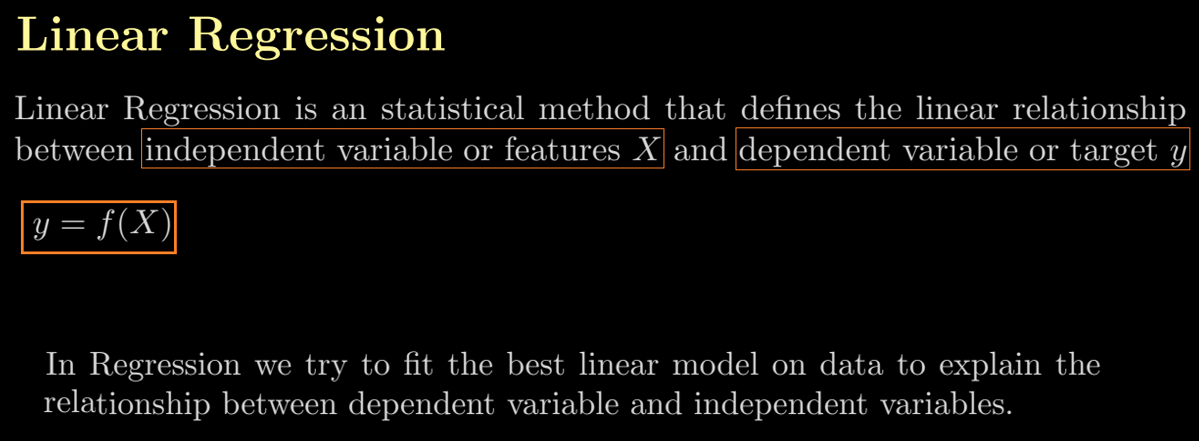

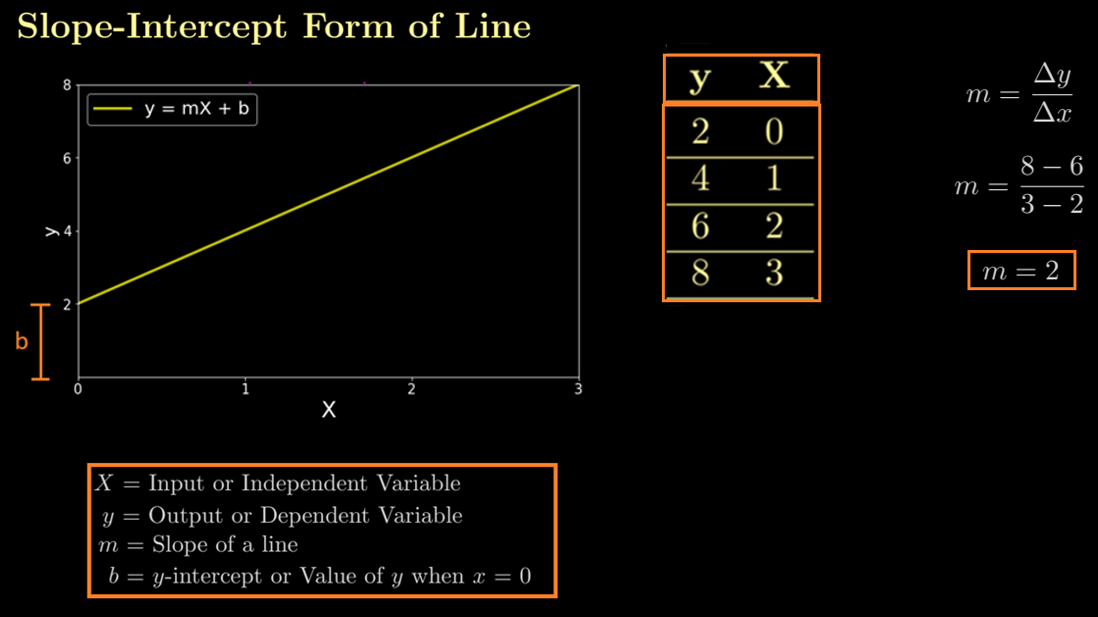

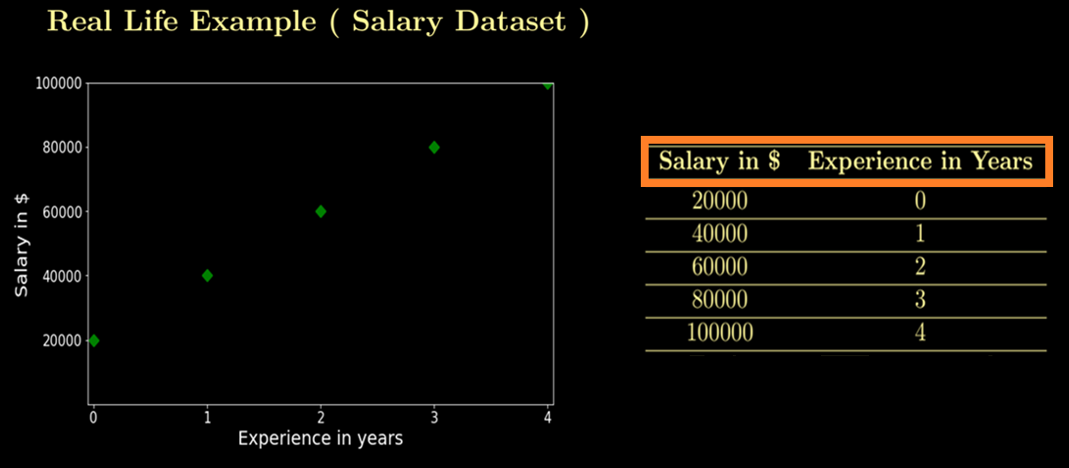

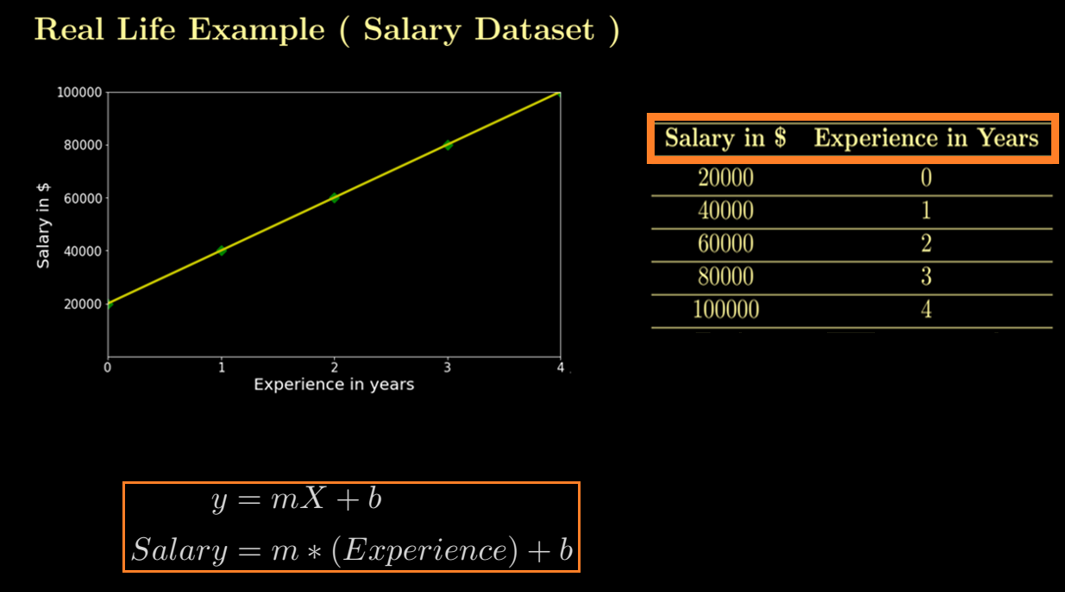

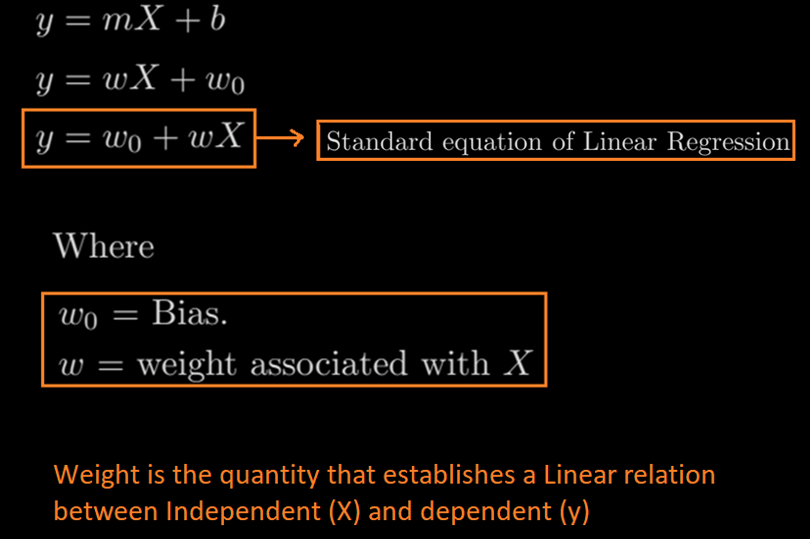

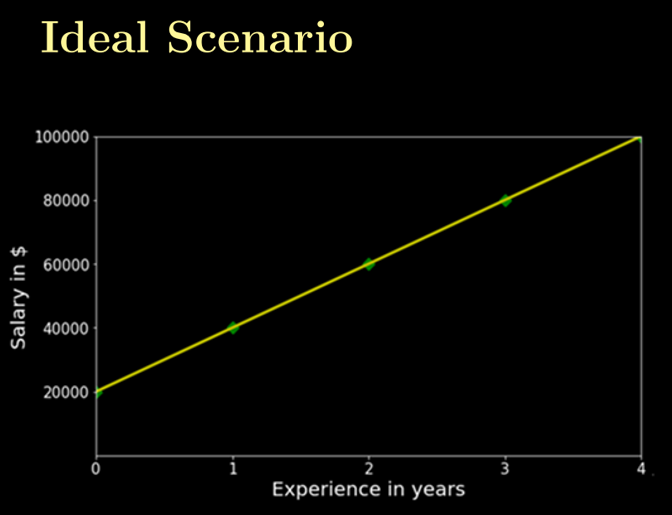

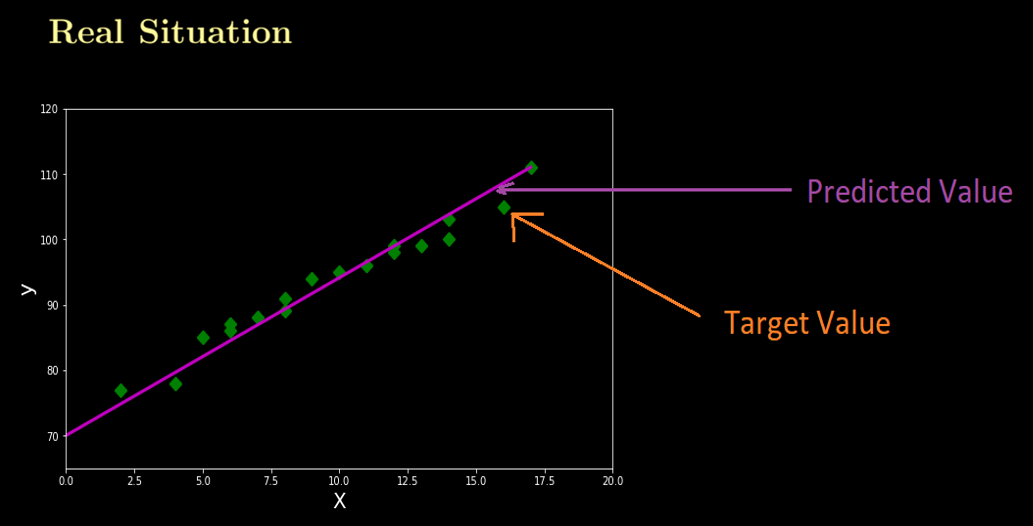

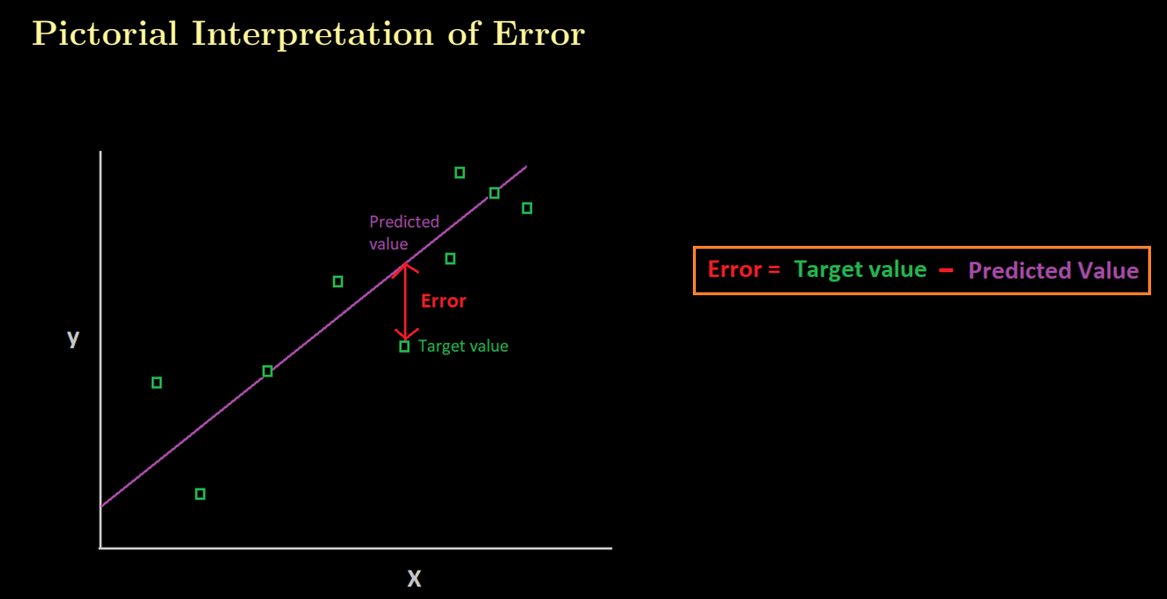

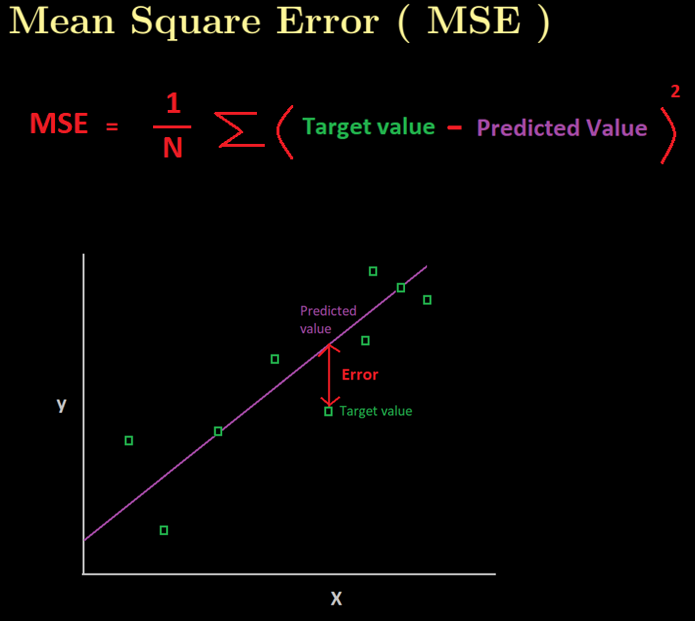

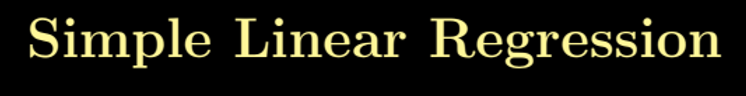

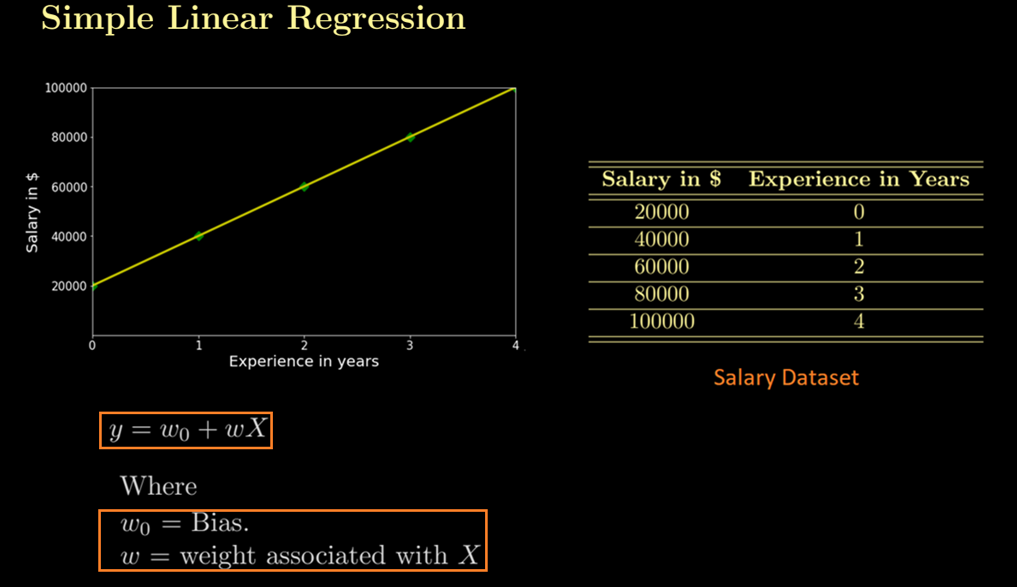

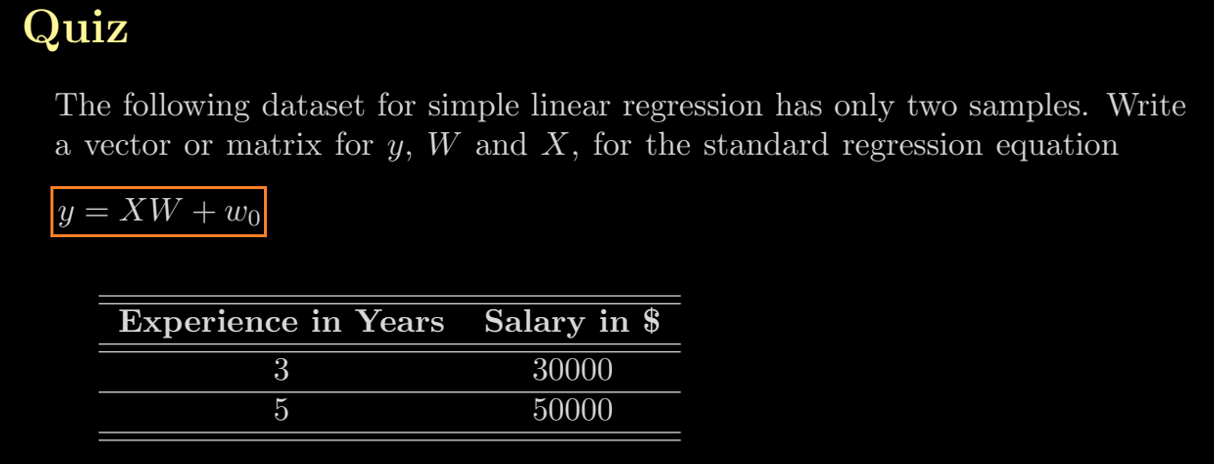

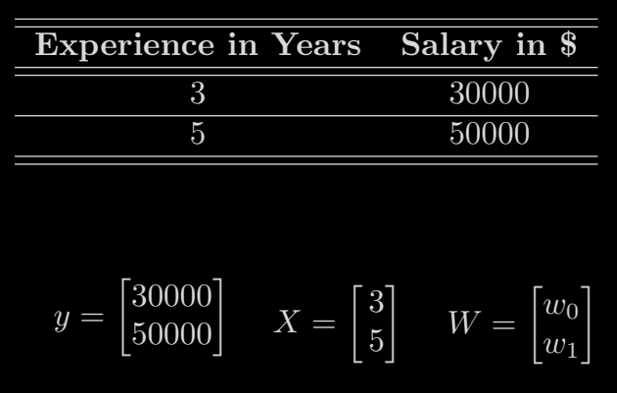

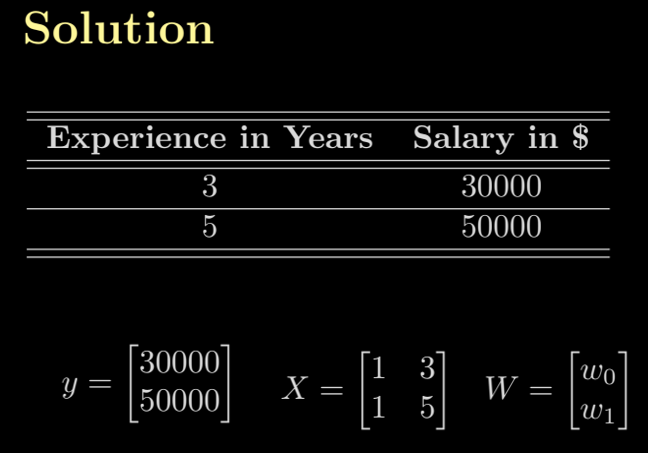

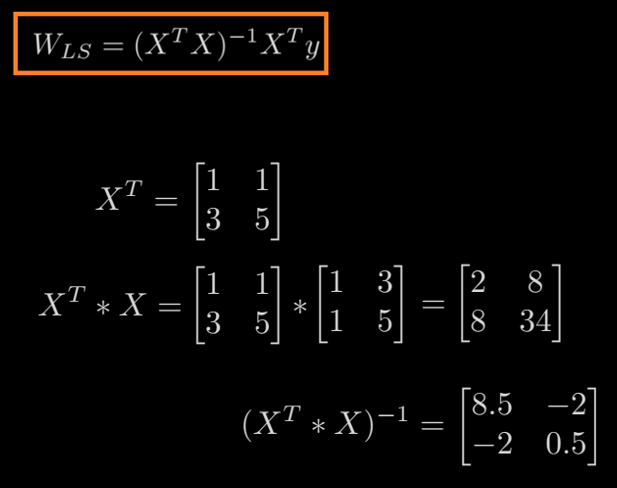

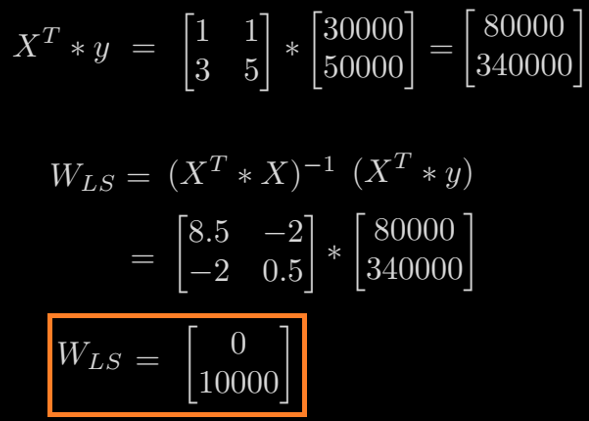

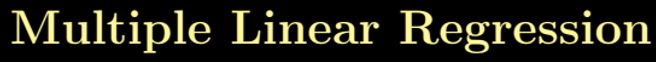

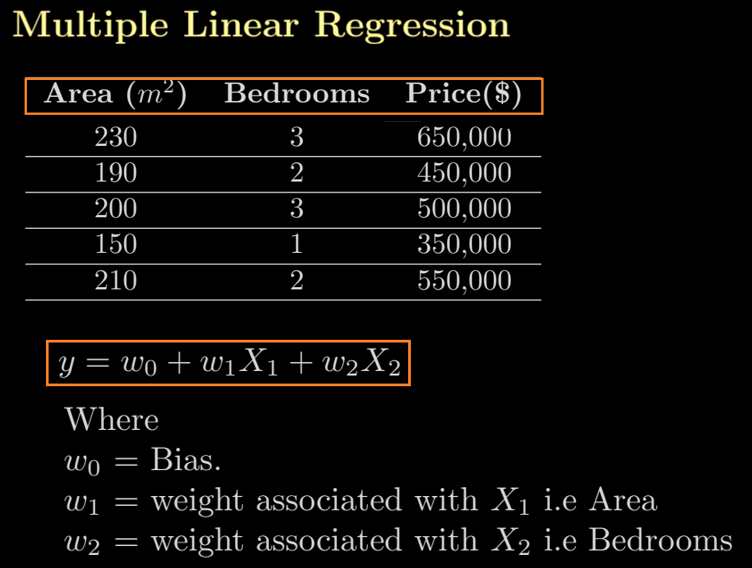

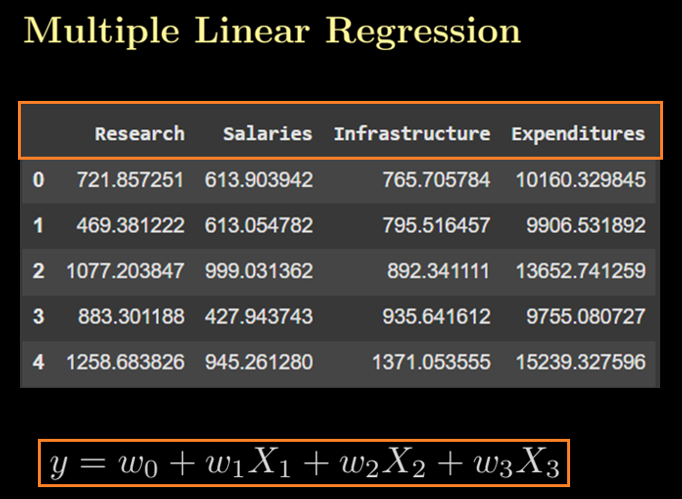

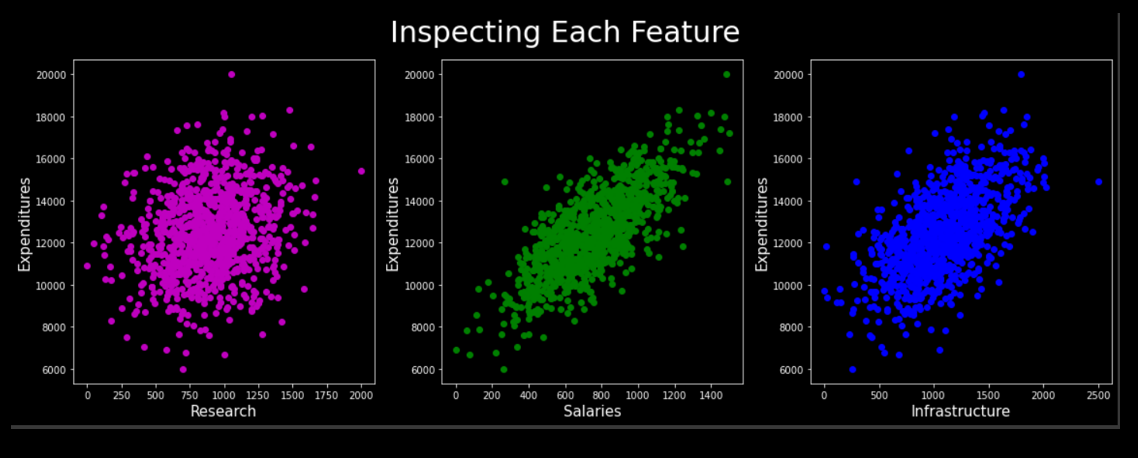

In [9]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

In [10]:
 #Sample dataset creation
data = {
    'Size': np.random.randint(500, 4000, 200),  # Size in square feet
    'Bedrooms': np.random.randint(1, 6, 200),   # Number of bedrooms
}
data['Price'] = 15000 + data['Size'] * 200 + data['Bedrooms'] * 7500  + np.random.normal(0, 10000, 200)

df = pd.DataFrame(data)

df

,Size,Bedrooms,Price
0,1477,4,335811.574911
1,1642,2,351092.745460
2,3929,1,804524.155088
3,3325,3,711336.336299
4,1292,2,296911.978950
...,...,...,...
195,3778,1,776496.274594
196,2303,1,485208.284055
197,2790,5,608146.970676
198,2854,3,609743.077901


In [11]:
# Define independent variables (X) and dependent variable (y)
X = df[['Size', 'Bedrooms']]
y = df['Price']

In [12]:
X

,Size,Bedrooms
0,1477,4
1,1642,2
2,3929,1
3,3325,3
4,1292,2
...,...,...
195,3778,1
196,2303,1
197,2790,5
198,2854,3


In [13]:
y

,Price
0,335811.574911
1,351092.745460
2,804524.155088
3,711336.336299
4,296911.978950
...,...
195,776496.274594
196,485208.284055
197,608146.970676
198,609743.077901


In [14]:
# Add a constant term to the independent variables
X = sm.add_constant(X)

In [15]:
X

,const,Size,Bedrooms
0,1.0,1477,4
1,1.0,1642,2
2,1.0,3929,1
3,1.0,3325,3
4,1.0,1292,2
...,...,...,...
195,1.0,3778,1
196,1.0,2303,1
197,1.0,2790,5
198,1.0,2854,3


In [16]:
model = sm.OLS(y, X).fit() # Fit the OLS regression model
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                 3.733e+04
Date:                Sun, 27 Apr 2025   Prob (F-statistic):          7.86e-255
Time:                        00:51:06   Log-Likelihood:                -2134.1
No. Observations:                 200   AIC:                             4274.
Df Residuals:                     197   BIC:                             4284.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.646e+04   2276.239      7.229      0.0

In [ ]:
# R-squared (0.998) indicates that 99.8% of the variance in house prices is explained by the model. This is a strong indicator of model fit.
# A large difference between r-squared and adjusted r-squared suggests that the model includes irrelevant predictors.
# The adjusted r-squared penalizes for unnecessary variables, so if you see a big difference between the two, you may have predictors that are strongly correlated.

In [ ]:
# F-statistic (37330) assesses the overall significance of the regression model. A high value indicates that at least one predictor variable is significantly related to house prices.
# This value shows that the model is statistically significant

In [ ]:
# Coefficients:
# Intercept (16000) suggests that when all predictors are zero (hypothetically), the base price is $16,000.
# Size (199.5) indicates that for each additional square foot, the price increases by $199.5.
# Bedrooms (7776) suggests that adding a bedroom increases the house price by $7589.

In [ ]:
# The t-statistics and p-values indicate that all predictors are statistically significant (p < 0.05), meaning they have a significant impact on house prices.

In [ ]:
# The log-likelihood value of a regression model is a way to measure the goodness of fit for a model. The higher the value of the log-likelihood, the better a model fits a dataset.

In [ ]:
# A lower AIC or BIC score indicates a better model. When we compare two models then the model with lower AIC and BIC is better.

# Different R^2 and adjusted R^2

In [17]:
df = pd.DataFrame({
    'X1': [1,0,0,1,1,0],
    'X2': [0,0,2,1,1,2],
    'y' : [199, 399, 488, 617, 787, 913]
})
df

,X1,X2,y
0,1,0,199
1,0,0,399
2,0,2,488
3,1,1,617
4,1,1,787
5,0,2,913


In [18]:
# Define independent variables (X) and dependent variable (y)
X = df[['X1', 'X2']]
y = df['y']

# Add a constant term to the independent variables
X = sm.add_constant(X)
model = sm.OLS(y, X).fit() # Fit the OLS regression model
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.498
Model:                            OLS   Adj. R-squared:                  0.163
Method:                 Least Squares   F-statistic:                     1.488
Date:                Sun, 27 Apr 2025   Prob (F-statistic):              0.356
Time:                        00:55:21   Log-Likelihood:                -39.286
No. Observations:                   6   AIC:                             84.57
Df Residuals:                       3   BIC:                             83.95
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        305.0667    222.221      1.373      0.2

/usr/local/lib/python3.11/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


# Import Libraries

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.api as sm

# Mount the drive and set the path

In [20]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [21]:
%cd /content/drive/MyDrive/Codes_Module03

/content/drive/MyDrive/Codes_Module03


In [22]:
# Load and prepare the data by mounting the drive and setting the path
data = pd.read_csv('Advertising.csv')

In [23]:
data.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [24]:
data.drop('Unnamed: 0', axis=1, inplace=True)

In [25]:
data.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [26]:
data.shape  # Find the total number of rows and columns

(200, 4)

In [27]:
# 1. Exploratory Data Analysis

# Basic information about the dataset
print("Dataset Info:")
print(data.info())
print("\nBasic Statistics:")
print(data.describe())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None

Basic Statistics:
               TV       radio   newspaper       sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   14.022500
std     85.854236   14.846809   21.778621    5.217457
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   10.375000
50%    149.750000   22.900000   25.750000   12.900000
75%    218.825000   36.525000   45.100000   17.400000
max    296.400000   49.600000  114.000000   27.000000


In [28]:
# Check for missing values
print("\nMissing Values:")
print(data.isnull().sum())


Missing Values:
TV           0
radio        0
newspaper    0
sales        0
dtype: int64


In [29]:
data.corr()

,TV,radio,newspaper,sales
TV,1.000000,0.054809,0.056648,0.782224
radio,0.054809,1.000000,0.354104,0.576223
newspaper,0.056648,0.354104,1.000000,0.228299
sales,0.782224,0.576223,0.228299,1.000000


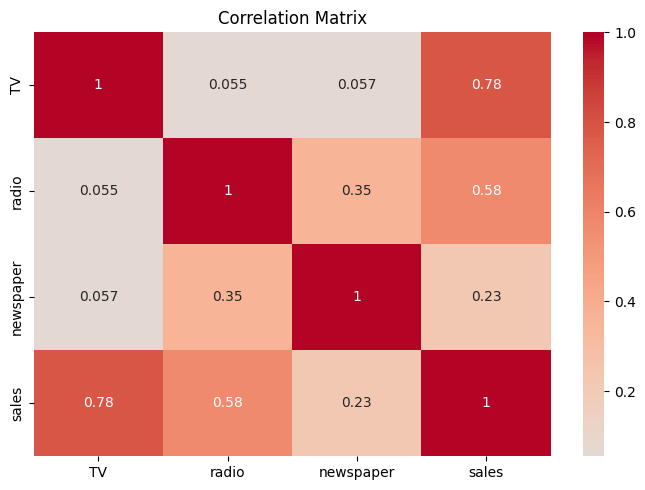

In [30]:
# Create correlation matrix and plot heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

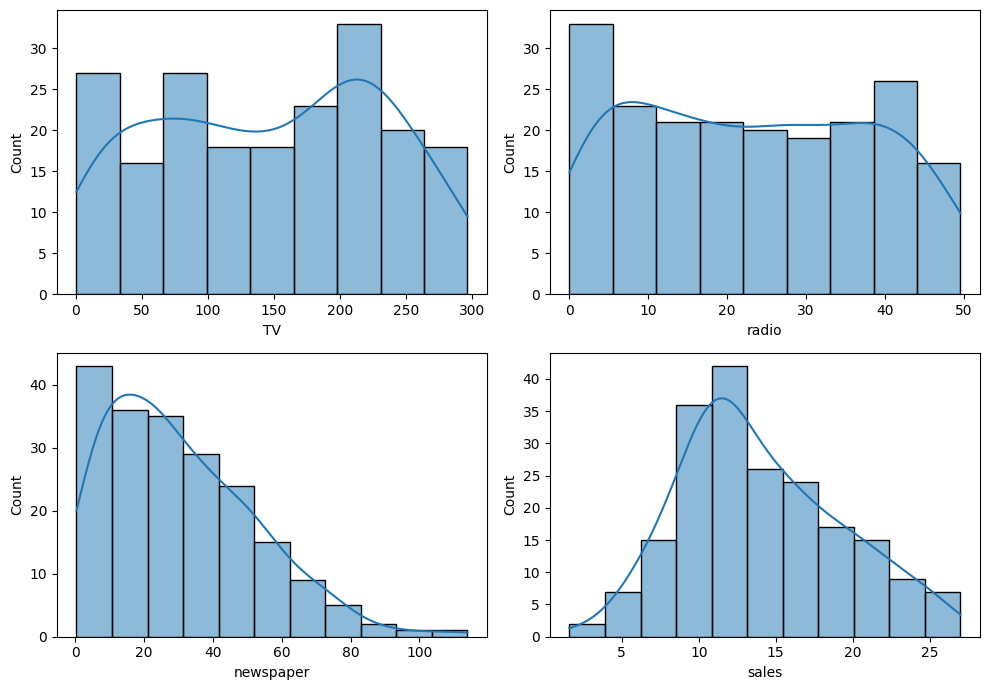

In [34]:
# Distribution plots for each variable
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
sns.histplot(data=data, x='TV', kde=True, ax=axes[0,0])
sns.histplot(data=data, x='radio', kde=True, ax=axes[0,1])
sns.histplot(data=data, x='newspaper', kde=True, ax=axes[1,0])
sns.histplot(data=data, x='sales', kde=True, ax=axes[1,1])
plt.tight_layout()
plt.show()


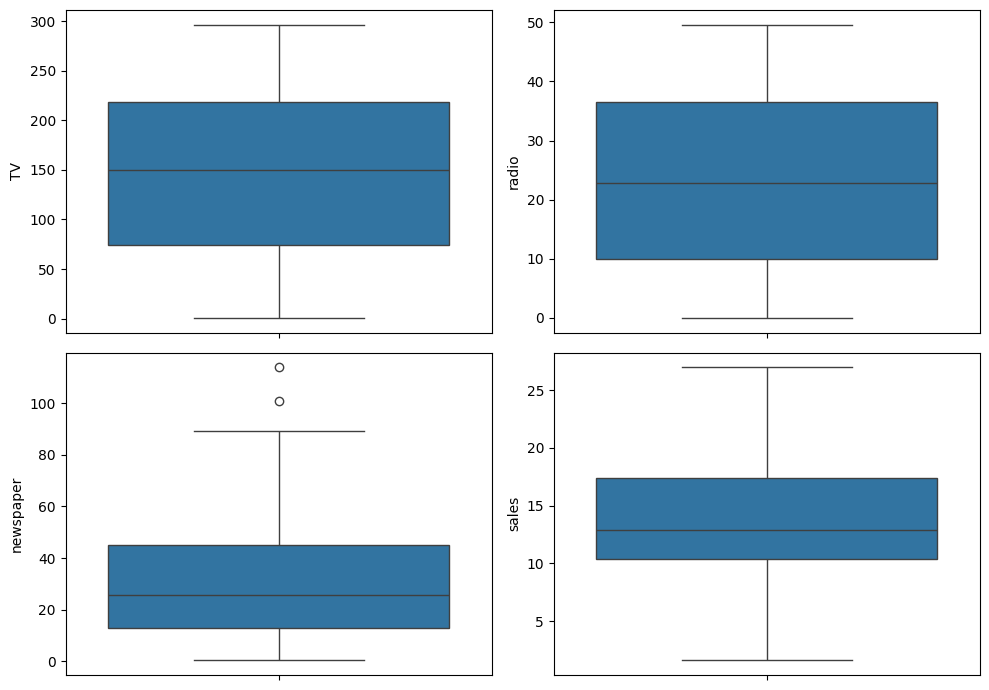

In [35]:
# Boxplots for outlier detection
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
sns.boxplot(data=data, y='TV', ax=axes[0,0])
sns.boxplot(data=data, y='radio', ax=axes[0,1])
sns.boxplot(data=data, y='newspaper', ax=axes[1,0])
sns.boxplot(data=data, y='sales', ax=axes[1,1])
plt.tight_layout()
plt.show()


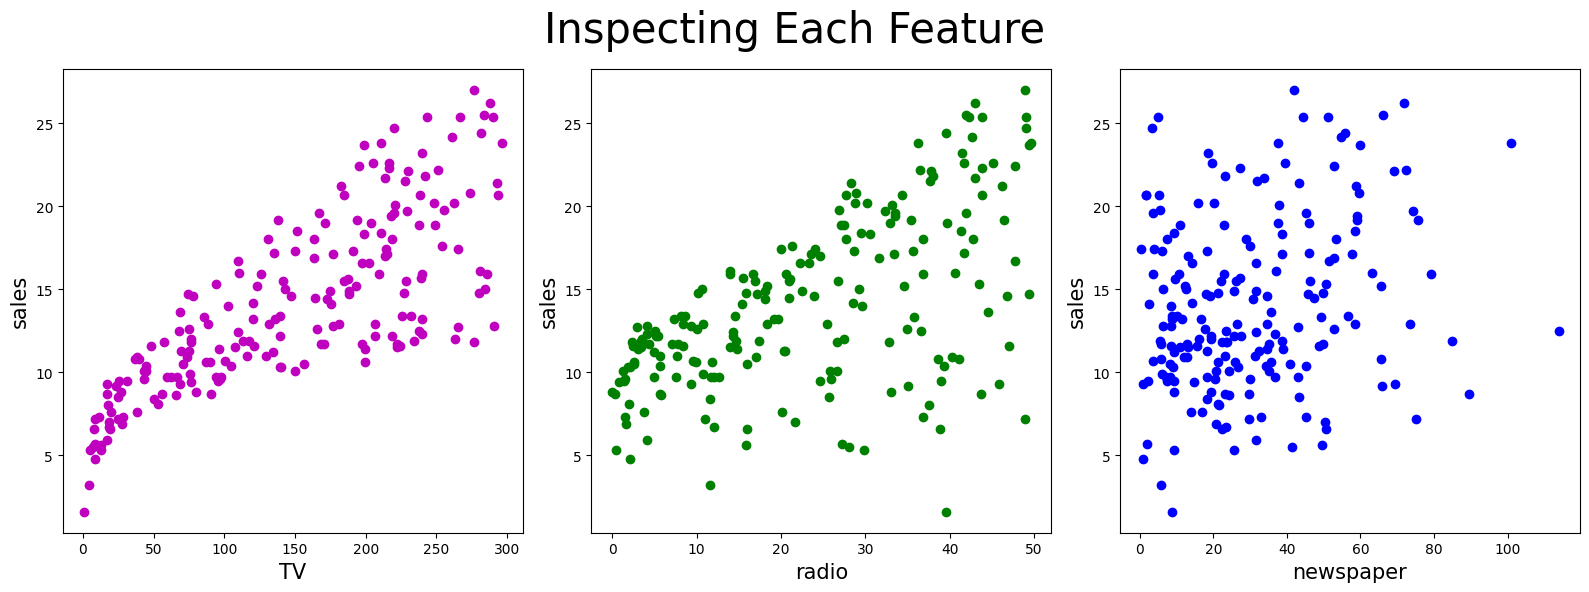

In [36]:
fig,axes = plt.subplots(nrows=1,ncols=3,figsize=(16,6))
plt.suptitle('Inspecting Each Feature', fontsize = 30)

axes[0].plot(data['TV'],data['sales'],'mo')
axes[0].set_ylabel("sales", fontsize = 15)
axes[0].set_xlabel("TV", fontsize = 15)

axes[1].plot(data['radio'],data['sales'],'go')
axes[1].set_ylabel("sales", fontsize = 15)
axes[1].set_xlabel("radio", fontsize = 15)

axes[2].plot(data['newspaper'],data['sales'],'bo')
axes[2].set_ylabel("sales", fontsize = 15)
axes[2].set_xlabel("newspaper", fontsize = 15)

plt.tight_layout();

In [37]:
 # Simple Linear Regression: Sales ~ TV

# Create the model
X_tv = data['TV']
y = data['sales']



In [38]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_tv = sc.fit_transform(X_tv.values.reshape(-1,1))

In [39]:
# Add constant for statsmodels
X_tv_sm = sm.add_constant(X_tv)

# Fit the model
model_tv = sm.OLS(y, X_tv_sm).fit()

# Print summary
print("\nSimple Linear Regression (Sales ~ TV):")
print(model_tv.summary())


Simple Linear Regression (Sales ~ TV):
                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.612
Model:                            OLS   Adj. R-squared:                  0.610
Method:                 Least Squares   F-statistic:                     312.1
Date:                Sun, 27 Apr 2025   Prob (F-statistic):           1.47e-42
Time:                        01:36:53   Log-Likelihood:                -519.05
No. Observations:                 200   AIC:                             1042.
Df Residuals:                     198   BIC:                             1049.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       

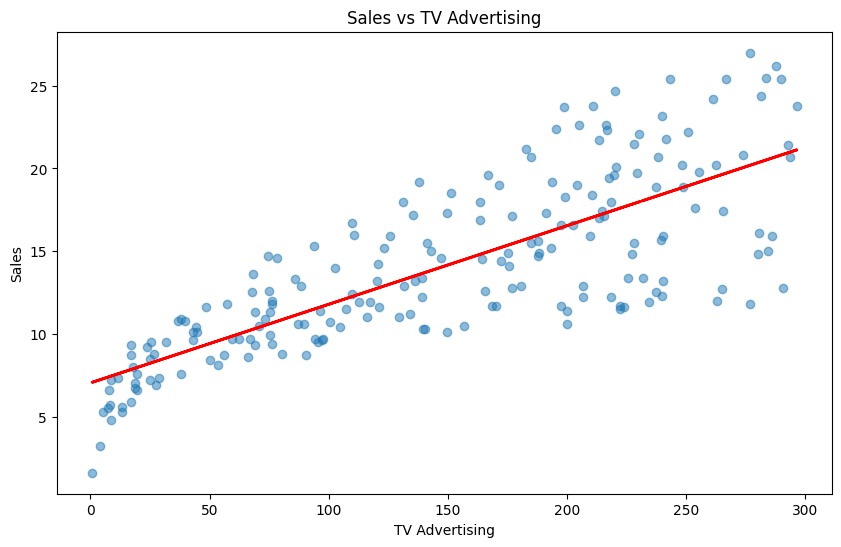

In [40]:
# Plot the regression line
plt.figure(figsize=(10, 6))
plt.scatter(data['TV'], data['sales'], alpha=0.5)
plt.plot(data['TV'], model_tv.predict(X_tv_sm), color='red', linewidth=2)
plt.xlabel('TV Advertising')
plt.ylabel('Sales')
plt.title('Sales vs TV Advertising')
plt.show()

In [41]:
# 3. Simple Linear Regression: Sales ~ Radio

# Create the model
X_radio = data[['radio']]

In [42]:
X_radio = sc.fit_transform(X_radio.values.reshape(-1,1))


Simple Linear Regression (Sales ~ Radio):
                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.332
Model:                            OLS   Adj. R-squared:                  0.329
Method:                 Least Squares   F-statistic:                     98.42
Date:                Sun, 27 Apr 2025   Prob (F-statistic):           4.35e-19
Time:                        01:37:37   Log-Likelihood:                -573.34
No. Observations:                 200   AIC:                             1151.
Df Residuals:                     198   BIC:                             1157.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const    

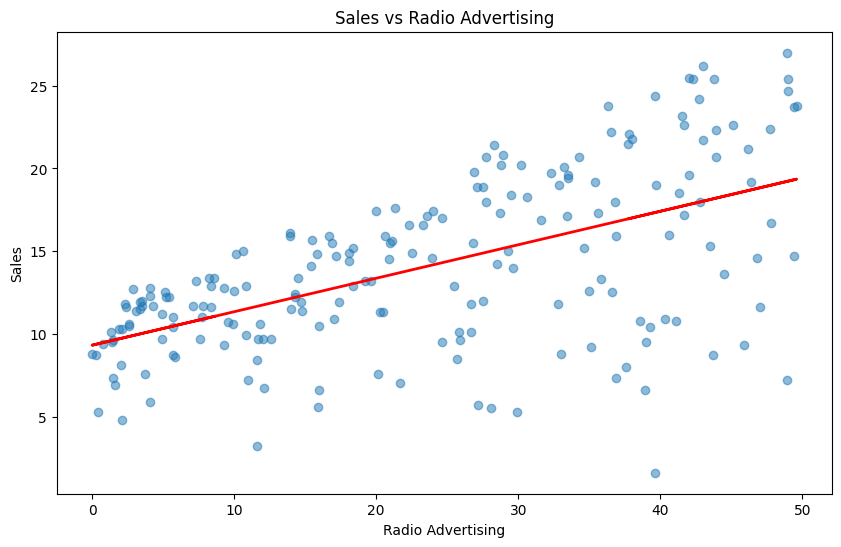

In [43]:
X_radio_sm = sm.add_constant(X_radio)

# Fit the model
model_radio = sm.OLS(y, X_radio_sm).fit()

# Print summary
print("\nSimple Linear Regression (Sales ~ Radio):")
print(model_radio.summary())

# Plot the regression line
plt.figure(figsize=(10, 6))
plt.scatter(data['radio'], data['sales'], alpha=0.5)
plt.plot(data['radio'], model_radio.predict(X_radio_sm), color='red', linewidth=2)
plt.xlabel('Radio Advertising')
plt.ylabel('Sales')
plt.title('Sales vs Radio Advertising')
plt.show()

In [44]:
# 4. Multiple Linear Regression

# Create the model
X_multi = data[['TV', 'radio', 'newspaper']]



In [45]:
X_multi = sc.fit_transform(X_multi.values)

In [46]:
X_multi_sm = sm.add_constant(X_multi)

# Fit the model
model_multi = sm.OLS(y, X_multi_sm).fit()

# Print summary
print("\nMultiple Linear Regression:")
print(model_multi.summary())

# Residual Analysis
residuals = model_multi.resid
fitted_values = model_multi.fittedvalues



Multiple Linear Regression:
                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:                Sun, 27 Apr 2025   Prob (F-statistic):           1.58e-96
Time:                        01:38:18   Log-Likelihood:                -386.18
No. Observations:                 200   AIC:                             780.4
Df Residuals:                     196   BIC:                             793.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         14.0225  

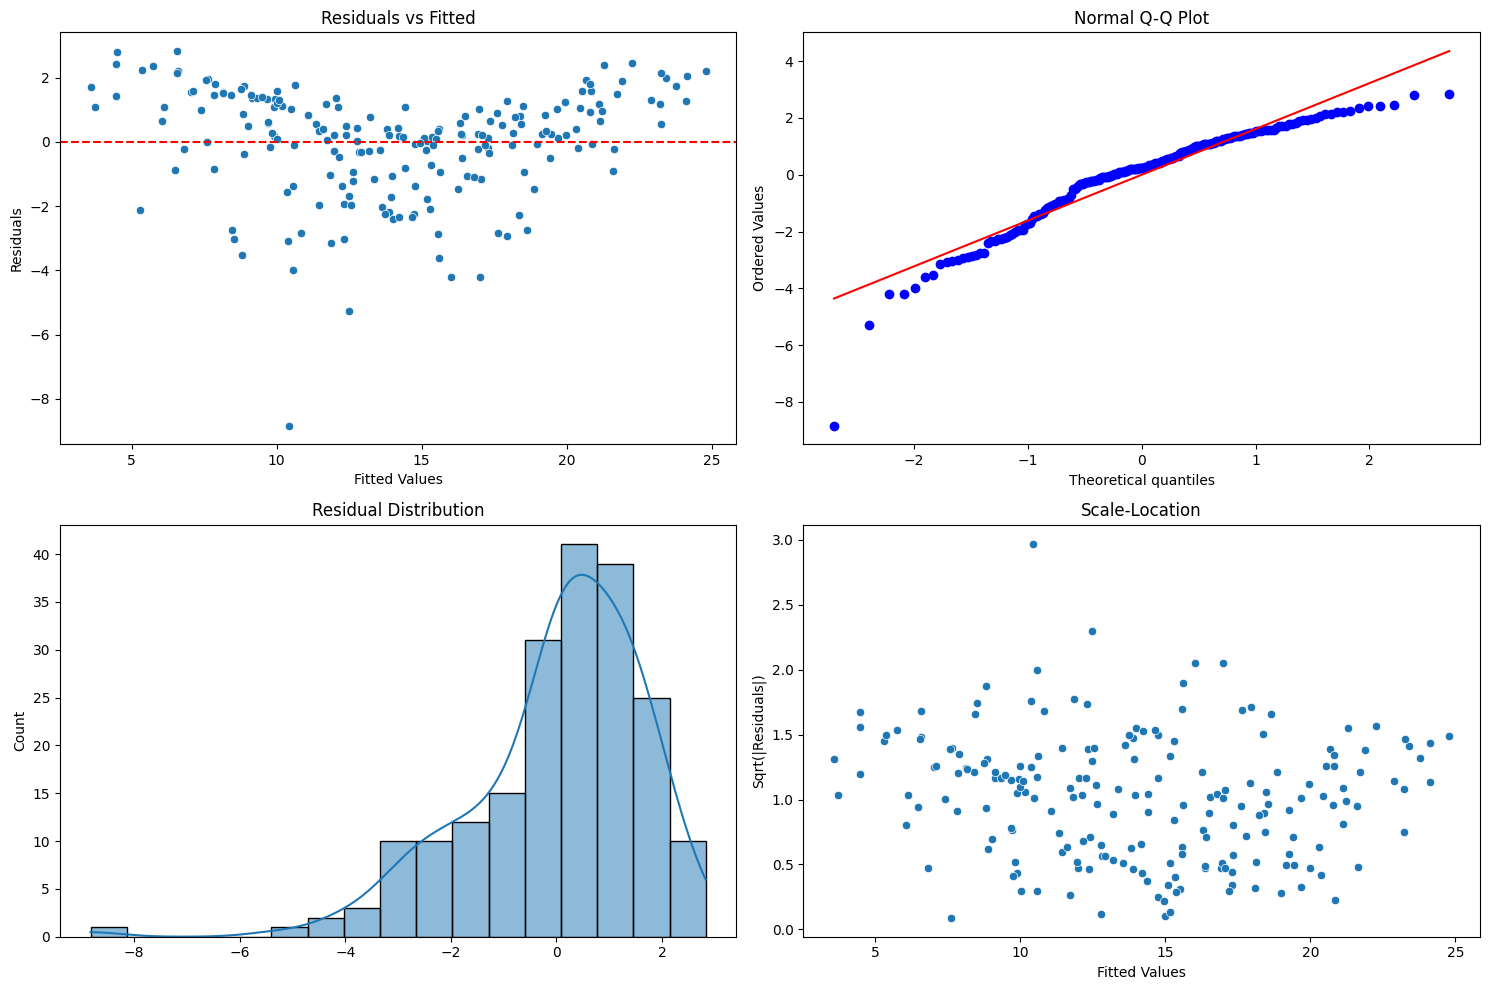


Normality Tests for Residuals:
Shapiro-Wilk test:
ShapiroResult(statistic=np.float64(0.9176652036187531), pvalue=np.float64(3.938571556266122e-09))

Descriptive Statistics of Residuals:
count    2.000000e+02
mean    -3.552714e-16
std      1.672757e+00
min     -8.827687e+00
25%     -8.908135e-01
50%      2.418018e-01
75%      1.189319e+00
max      2.829223e+00
dtype: float64


In [47]:

# Get residuals and fitted values
residuals = model_multi.resid
fitted_values = model_multi.fittedvalues

# Create subplots for residual analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Residuals vs Fitted Values
sns.scatterplot(x=fitted_values, y=residuals, ax=axes[0,0])
axes[0,0].axhline(y=0, color='r', linestyle='--')
axes[0,0].set_xlabel('Fitted Values')
axes[0,0].set_ylabel('Residuals')
axes[0,0].set_title('Residuals vs Fitted')

# 2. QQ Plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[0,1])
axes[0,1].set_title('Normal Q-Q Plot')

# 3. Residual Distribution
sns.histplot(residuals, kde=True, ax=axes[1,0])
axes[1,0].set_title('Residual Distribution')

# 4. Scale-Location Plot
sns.scatterplot(x=fitted_values, y=np.sqrt(np.abs(residuals)), ax=axes[1,1])
axes[1,1].set_xlabel('Fitted Values')
axes[1,1].set_ylabel('Sqrt(|Residuals|)')
axes[1,1].set_title('Scale-Location')

# Adjust layout and display
plt.tight_layout()
plt.show()

# Additional numerical tests for normality
print("\nNormality Tests for Residuals:")
print("Shapiro-Wilk test:")
print(stats.shapiro(residuals))

print("\nDescriptive Statistics of Residuals:")
print(pd.Series(residuals).describe())

In [ ]:
# Q-Q plot is called quantile-quantile plot. Q-Q plots are used to find if the data or empirical data
# matches the theoretical normal distribution. Quantile is slightly different from quartile. Quantile
# divides the sorted data into any number of equal parts where as quartile which is the subset of the quantile
# divides the the data into fours parts with the three dividing points called the first quartile (Q1), second quartile
# (Q2), and third quartile (Q3).

In [ ]:
# The statistics in the Shapiro test should be closed to 1 if the distribution is to be close to Normal.
# The p-value should be gretaer than 0.05 to keep the null hypothesis that samples comes from Normal distribution.

#  Machine Learning Approach

In [48]:
data

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


In [49]:
X = data.iloc[:,:-1].values

In [50]:
X

array([[230.1,  37.8,  69.2],
       [ 44.5,  39.3,  45.1],
       [ 17.2,  45.9,  69.3],
       [151.5,  41.3,  58.5],
       [180.8,  10.8,  58.4],
       [  8.7,  48.9,  75. ],
       [ 57.5,  32.8,  23.5],
       [120.2,  19.6,  11.6],
       [  8.6,   2.1,   1. ],
       [199.8,   2.6,  21.2],
       [ 66.1,   5.8,  24.2],
       [214.7,  24. ,   4. ],
       [ 23.8,  35.1,  65.9],
       [ 97.5,   7.6,   7.2],
       [204.1,  32.9,  46. ],
       [195.4,  47.7,  52.9],
       [ 67.8,  36.6, 114. ],
       [281.4,  39.6,  55.8],
       [ 69.2,  20.5,  18.3],
       [147.3,  23.9,  19.1],
       [218.4,  27.7,  53.4],
       [237.4,   5.1,  23.5],
       [ 13.2,  15.9,  49.6],
       [228.3,  16.9,  26.2],
       [ 62.3,  12.6,  18.3],
       [262.9,   3.5,  19.5],
       [142.9,  29.3,  12.6],
       [240.1,  16.7,  22.9],
       [248.8,  27.1,  22.9],
       [ 70.6,  16. ,  40.8],
       [292.9,  28.3,  43.2],
       [112.9,  17.4,  38.6],
       [ 97.2,   1.5,  30. ],
       [26

In [51]:
y = data.iloc[:,-1].values.reshape(-1,1)

In [52]:
y

array([[22.1],
       [10.4],
       [ 9.3],
       [18.5],
       [12.9],
       [ 7.2],
       [11.8],
       [13.2],
       [ 4.8],
       [10.6],
       [ 8.6],
       [17.4],
       [ 9.2],
       [ 9.7],
       [19. ],
       [22.4],
       [12.5],
       [24.4],
       [11.3],
       [14.6],
       [18. ],
       [12.5],
       [ 5.6],
       [15.5],
       [ 9.7],
       [12. ],
       [15. ],
       [15.9],
       [18.9],
       [10.5],
       [21.4],
       [11.9],
       [ 9.6],
       [17.4],
       [ 9.5],
       [12.8],
       [25.4],
       [14.7],
       [10.1],
       [21.5],
       [16.6],
       [17.1],
       [20.7],
       [12.9],
       [ 8.5],
       [14.9],
       [10.6],
       [23.2],
       [14.8],
       [ 9.7],
       [11.4],
       [10.7],
       [22.6],
       [21.2],
       [20.2],
       [23.7],
       [ 5.5],
       [13.2],
       [23.8],
       [18.4],
       [ 8.1],
       [24.2],
       [15.7],
       [14. ],
       [18. ],
       [ 9.3],
       [ 9

In [53]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [54]:
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [55]:
from sklearn.linear_model import LinearRegression

In [56]:
Model_Reg = LinearRegression()

In [57]:
Model_Reg.fit(X_train, y_train)

LinearRegression()

In [58]:
print(Model_Reg.coef_, Model_Reg.intercept_)

[[3.76419618 2.79230665 0.05597551]] [14.1]


In [59]:
y_pred = Model_Reg.predict(X_test)

In [60]:
from sklearn import metrics
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print('MAE:', metrics.mean_absolute_error(y_test, y_pred))
print('R2:', metrics.r2_score(y_test, y_pred))

RMSE: 1.7815996615334504
MAE: 1.4607567168117601
R2: 0.899438024100912
